# 02 — Exploratory Data Analysis (EDA)

Goal: Validate the cleaned dataset, explore revenue distribution, identify trends over time, and confirm key business drivers (top products/customers/countries).


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import os

print("Current working directory:", os.getcwd())
print("\nFiles here:", os.listdir())

Current working directory: C:\Users\chari\ecommerce-bi-analytics\python

Files here: ['.gitkeep', '.ipynb_checkpoints', '01_data_cleaning.ipynb', '02_eda_analysis.ipynb']


In [2]:
# Check cleaned data folder
print(os.listdir("../data/cleaned"))


['.gitkeep', 'online_retail_cleaned.csv']


In [3]:
import os
print("RAW:", os.listdir("../data/raw"))
print("CLEANED:", os.listdir("../data/cleaned"))


RAW: ['online_retail_sample.xlsx']
CLEANED: ['.gitkeep', 'online_retail_cleaned.csv']


In [4]:
import pandas as pd

cleaned_file = "../data/cleaned/online_retail_cleaned.csv"
df = pd.read_csv(cleaned_file)

print("EDA loaded shape:", df.shape)
df.head()


EDA loaded shape: (4917, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [5]:
df.info()
df.isna().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4917 entries, 0 to 4916
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     4917 non-null   int64  
 1   StockCode     4917 non-null   object 
 2   Description   4917 non-null   object 
 3   Quantity      4917 non-null   int64  
 4   InvoiceDate   4917 non-null   object 
 5   UnitPrice     4917 non-null   float64
 6   CustomerID    3724 non-null   float64
 7   Country       4917 non-null   object 
 8   Revenue       4917 non-null   float64
 9   InvoiceMonth  4917 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 384.3+ KB


,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue
count,4917.000000,4917.000000,4917.000000,3724.000000,4917.000000
mean,536592.446614,11.457799,3.794208,15919.373792,21.162064
std,122.344183,58.872776,13.309655,1723.892321,62.389716
min,536365.000000,1.000000,0.100000,12431.000000,0.290000
25%,536532.000000,1.000000,1.250000,14606.000000,4.200000
50%,536592.000000,3.000000,2.510000,15892.000000,10.200000
75%,536667.000000,12.000000,4.210000,17841.000000,17.850000
max,536836.000000,2880.000000,607.490000,18239.000000,1627.200000


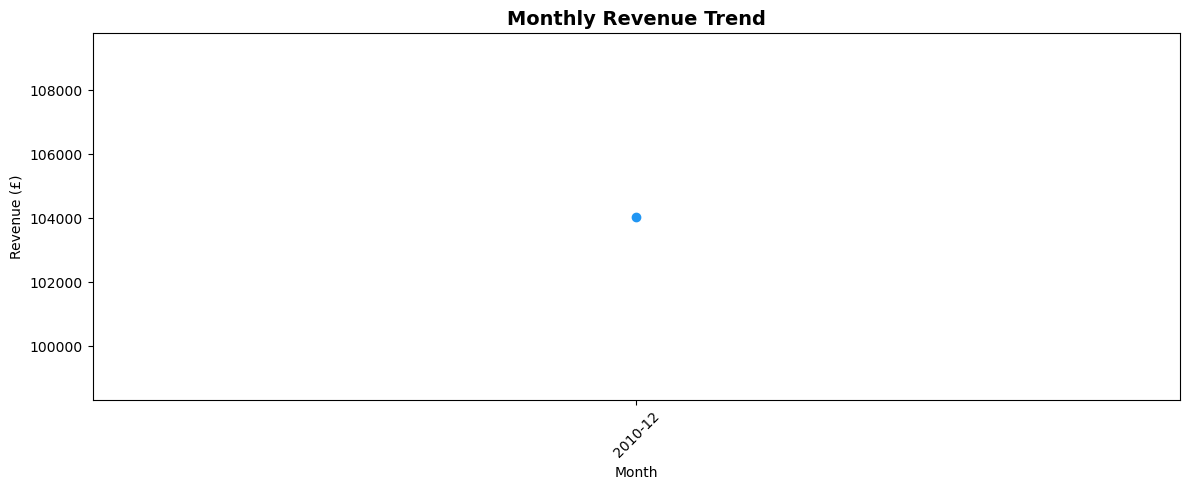

Top revenue month: 2010-12


In [6]:
# Monthly Revenue Trend
monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum().reset_index()
monthly_revenue.columns = ["Month", "Revenue"]

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], marker="o", color="#2196F3", linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_revenue.png", dpi=150)
plt.show()
print("Top revenue month:", monthly_revenue.loc[monthly_revenue["Revenue"].idxmax(), "Month"])

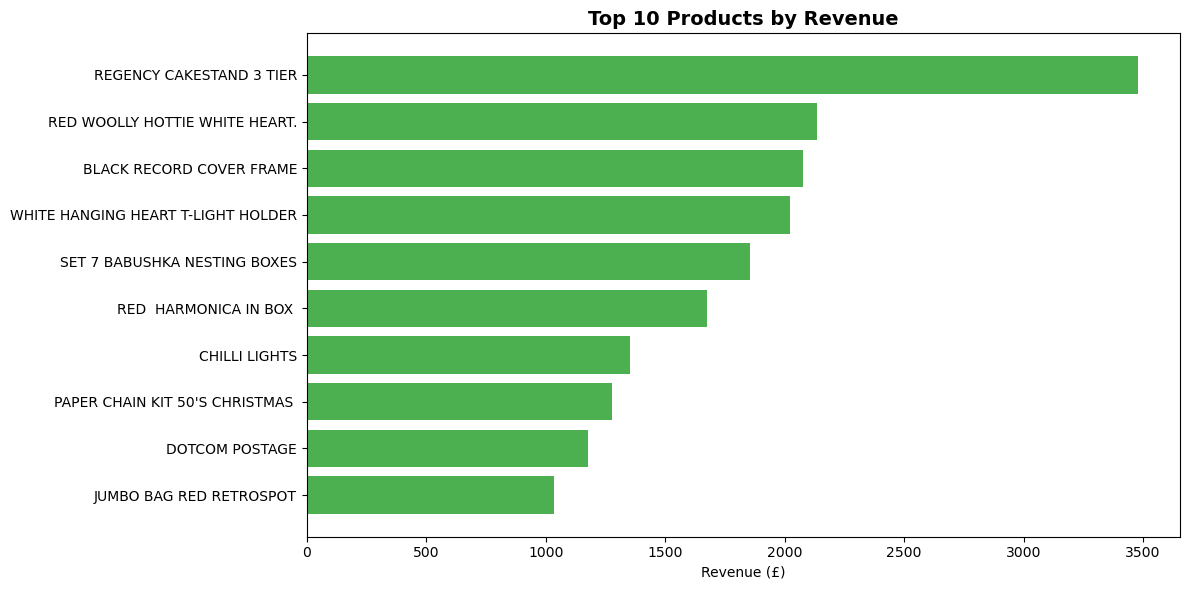

In [7]:
# Top 10 Products by Revenue
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
plt.barh(top_products["Description"], top_products["Revenue"], color="#4CAF50")
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../images/top_10_products_by_revenue.png", dpi=150)
plt.show()

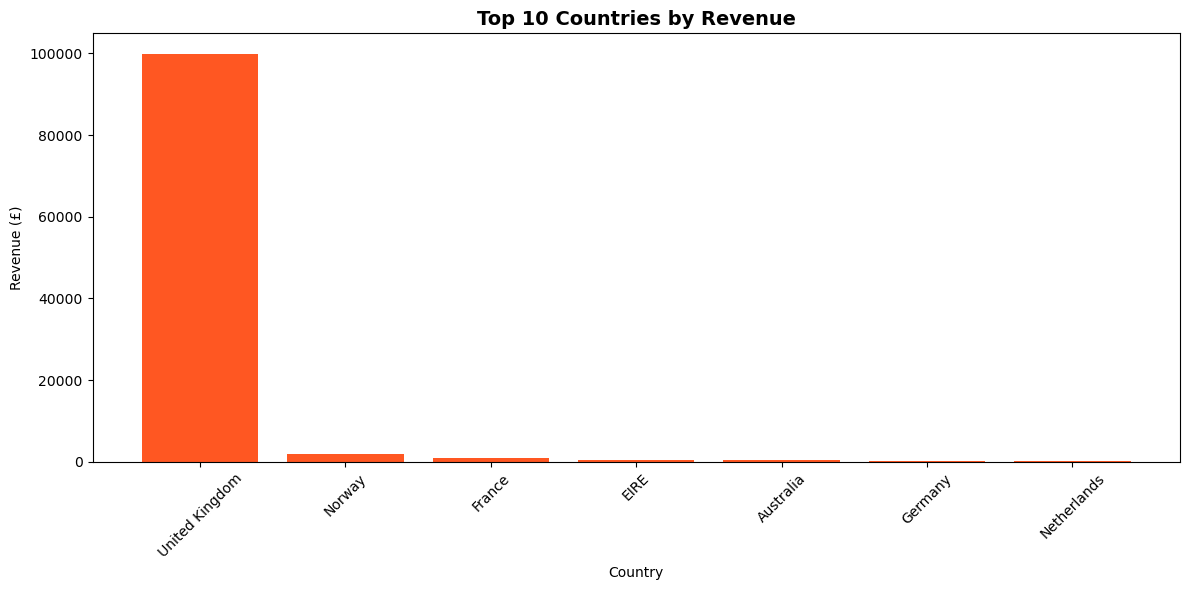

In [8]:
# Revenue by Country
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
plt.bar(country_revenue["Country"], country_revenue["Revenue"], color="#FF5722")
plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/revenue_by_country.png", dpi=150)
plt.show()

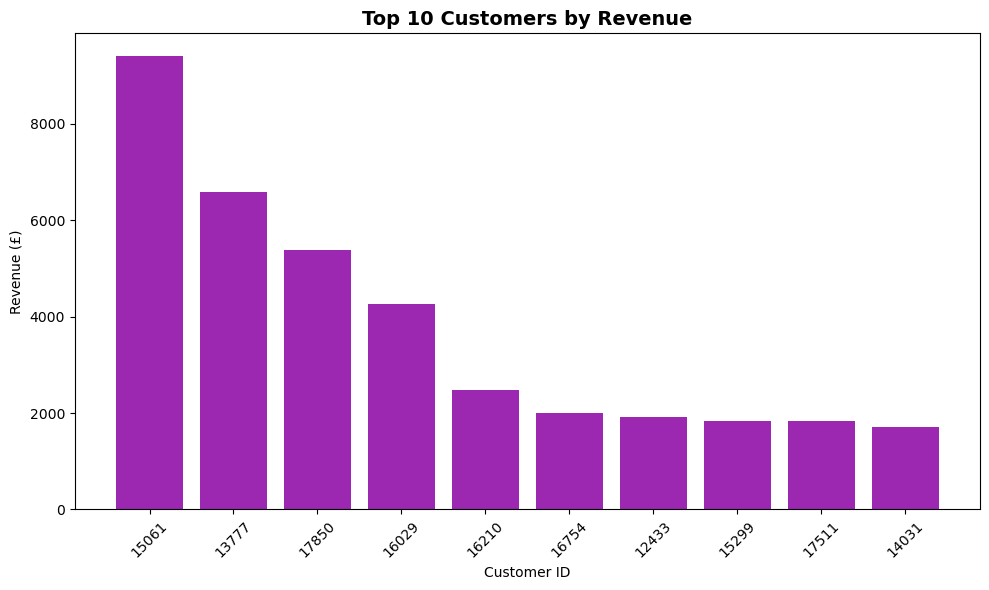

In [9]:
# Top 10 Customers by Revenue
top_customers = df.dropna(subset=["CustomerID"])
top_customers = top_customers.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()
top_customers["CustomerID"] = top_customers["CustomerID"].astype(int).astype(str)

plt.figure(figsize=(10, 6))
plt.bar(top_customers["CustomerID"], top_customers["Revenue"], color="#9C27B0")
plt.title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_10_customers_by_revenue.png", dpi=150)
plt.show()

In [10]:
# Key Business KPIs
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
aov = total_revenue / total_orders

print("=" * 40)
print("KEY BUSINESS KPIs")
print("=" * 40)
print(f"Total Revenue:        £{total_revenue:,.2f}")
print(f"Total Orders:         {total_orders:,}")
print(f"Total Customers:      {total_customers:,}")
print(f"Average Order Value:  £{aov:,.2f}")
print("=" * 40)

# Repeat customer rate
order_counts = df.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_customers = (order_counts > 1).sum()
total_cust = order_counts.count()
repeat_rate = (repeat_customers / total_cust) * 100
print(f"Repeat Customer Rate: {repeat_rate:.1f}%")
print("=" * 40)

KEY BUSINESS KPIs
Total Revenue:        £104,053.87
Total Orders:         259
Total Customers:      179
Average Order Value:  £401.75
Repeat Customer Rate: 12.8%
